In [12]:
%load_ext autoreload
%autoreload 2
import numpy as np
import awkward as ak
from matplotlib import pyplot as plt
import mplhep as hep
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import LogLocator, ScalarFormatter
hep.style.use("CMS")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [104]:
from collections import namedtuple
import uproot as up
from scipy.stats import binned_statistic_dd

# ScaleFactors = namedtuple('ScaleFactors', ['pt_sfs', 'mass_sfs', 'bin_edges', 'counts'])
ScaleFactors = namedtuple('ScaleFactors', ['sfs', 'bin_edges', 'counts'])
Thresholds = namedtuple('Thresholds', ['l1_pt', 'l1_mass', 'gen_pt', 'gen_mass'])


class Jet:

    required_variables = ["pt", "eta", "phi", "mass", "genpt", "geneta", "genphi", "genmass", "event"]    # variables required for the class to function
    # l1_vars = ["pt", "mass", "eta"]    # variables to bin on
    l1_vars = ["pt", "eta"]    # variables to bin on
    # l1_vars = ["mass", "eta"]    # variables to bin on
    
    def __init__(self, path: str, branch: str = "outnano/Jets",
                 keys: dict = {"jet_pt": "pt", "jet_eta_phys": "eta", "jet_phi_phys": "phi", "jet_mass": "mass", "jet_genmatch_pt": "genpt", "jet_genmatch_eta": "geneta", "jet_genmatch_phi": "genphi", "jet_genmatch_mass": "genmass", "event": "event"}):
        for v in Jet.required_variables:
            if v not in list(keys.values()): raise Exception("A required variable is not defined in keys!")
        self.data = self.load(path, branch, keys)


    @staticmethod
    def load(path, branch, keys):
        print("Loading data...")
        with up.open(path)[branch] as file:
            data = file.arrays( filter_name=list( keys.keys() ) )
            reject_mask = file["jet_reject"].array() == False if "jet_reject" in file.keys() else ak.ones_like(data["event"], dtype=bool)
        
        data = ak.Array({keys[field]: data[field] for field in data.fields})[reject_mask]
        print("Data loaded!\n")
        return data


    @staticmethod
    def preprocess(data, eta_limit: int = 5.0, l1_pt_range: tuple[float, float] = (0., 0.), l1_mass_range: tuple[float, float] = (0., 0.),
                   gen_pt_range: tuple[float, float] = (0., 1000.), gen_mass_range: tuple[float, float] = (0., 182.)
                   ) -> ak.highlevel.Array:
        
        # get jet 4-vector
        def _get_4vec(jets, gen=False):
            prefix = "gen" if gen else ""
            ptvar, etavar, phivar, massvar = prefix+"pt", prefix+"eta", prefix+"phi", prefix+"mass"

            px = jets[ptvar] * np.cos(jets[phivar])
            py = jets[ptvar] * np.sin(jets[phivar])
            pz = jets[ptvar] * np.sinh(jets[etavar])
            p2 = px**2 + py**2 + pz**2
            en = np.sqrt(p2 + jets[massvar]**2)

            jets[prefix+"en"], jets[prefix+"px"], jets[prefix+"py"], jets[prefix+"pz"] = en, px, py, pz
            return jets

        data = _get_4vec(data, gen=False)
        data = _get_4vec(data, gen=True)

        # filter out gen masses outside of range
        mask = (data["genmass"] > gen_mass_range[0]) & (data["genmass"] < gen_mass_range[1])
        mask = mask & ( data["genpt"] > gen_pt_range[0]) & (data["genpt"] < gen_pt_range[1] )
        
        mask = mask & ( data["mass"] > l1_mass_range[0]) & (data["mass"] < l1_mass_range[1] )
        mask = mask & ( data["pt"] > l1_pt_range[0]) & (data["pt"] < l1_pt_range[1] )

        mask = mask & (abs(data["eta"]) < eta_limit)
        return data[mask]
    

    @staticmethod
    def test_train_split(data, train_ratio = 0.75):
        data = data[ np.random.permutation(len(data)) ]
        splitIdx = int(len(data) * train_ratio)
        data_train, data_test = data[:splitIdx], data[splitIdx:]
        return data_train, data_test
    

    @staticmethod
    def response(data_train, eps = 1e-3):

        import vector
        vector.register_awkward()

        l1_vec, gen_vec = data_train[["en", "px", "py", "pz"]], data_train[["genen", "genpx", "genpy", "genpz"]]

        l1_vec["E"] = l1_vec["en"]
        gen_vec["E"], gen_vec["px"], gen_vec["py"], gen_vec["pz"] = gen_vec["genen"], gen_vec["genpx"], gen_vec["genpy"], gen_vec["genpz"]

        l1_vec, gen_vec = l1_vec[["px", "py", "pz", "E"]], gen_vec[["px", "py", "pz", "E"]]
        l1_vec, gen_vec = ak.with_name(l1_vec, name="Momentum4D"), ak.with_name(gen_vec, name="Momentum4D")

        D = l1_vec.dot(l1_vec)
        N = gen_vec.dot(l1_vec)

        pt_response = (data_train["pt"] + eps) / (data_train["genpt"] + eps)
        mass_response = (data_train["mass"] + eps) / (data_train["genmass"] + eps)
        energy_response = (data_train["en"] + eps) / (data_train["genen"] + eps)
        px_response = (data_train["px"] + eps) / (data_train["genpx"] + eps)
        py_response = (data_train["py"] + eps) / (data_train["genpy"] + eps)
        pz_response = (data_train["pz"] + eps) / (data_train["genpz"] + eps)
        return pt_response, mass_response, energy_response, px_response, py_response, pz_response, D, N
    

    @staticmethod
    def histogram(data_train: ak.highlevel.Array, responses, D, N,
                #   pt_response, mass_response, energy_response, px_response, py_response, pz_response, 
                  nBins: int = 100, nans: int = 1, how: str = "mean" ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:

        bin_edges = []
        vals = []
        for v in Jet.l1_vars:
            if (v == "pt") | (v=="mass"):
                values = ak.to_numpy(data_train[v])
                vals.append( values )
                bin_edges.append( np.unique( np.quantile(values, np.linspace(0, 1, nBins + 1)) ) )
            elif v == "eta":
                vals.append( ak.to_numpy(data_train["eta"]) )
                bin_edges.append( np.linspace(-2.5, 2.5, 11) )
            else:
                raise Exception("Invalid variable in l1_vars!")

        train_numpy = np.column_stack(vals)

        sfs = []
        for response in responses:
            resp = binned_statistic_dd( train_numpy, ak.to_numpy(response), statistic = how, bins = bin_edges )[0]
            sf = 1.0 / np.nan_to_num(resp, nan=nans)
            sfs.append(sf)
        # pt_resp = binned_statistic_dd( train_numpy, ak.to_numpy(pt_response), statistic = how, bins = bin_edges )[0]
        # mass_resp = binned_statistic_dd( train_numpy, ak.to_numpy(mass_response), statistic = how, bins = bin_edges )[0]
        # energy_resp = binned_statistic_dd( train_numpy, ak.to_numpy(energy_response), statistic = how, bins = bin_edges )[0]
        # px_resp = binned_statistic_dd( train_numpy, ak.to_numpy(px_response), statistic = how, bins = bin_edges )[0]
        # py_resp = binned_statistic_dd( train_numpy, ak.to_numpy(py_response), statistic = how, bins = bin_edges )[0]
        # pz_resp = binned_statistic_dd( train_numpy, ak.to_numpy(pz_response), statistic = how, bins = bin_edges )[0]
        counts = binned_statistic_dd(train_numpy, np.ones(len(train_numpy)), statistic='count', bins=bin_edges)[0]

        N_sum = binned_statistic_dd(train_numpy, ak.to_numpy(N), statistic='sum', bins=bin_edges)[0]
        D_sum = binned_statistic_dd(train_numpy, ak.to_numpy(D), statistic='sum', bins=bin_edges)[0]
        k = np.nan_to_num(N_sum / D_sum, nan=nans)
        # pt_sf_raw = 1.0 / pt_resp
        # mass_sf_raw = 1.0 / mass_resp

        # if len(Jet.l1_vars) == 3:
        #     pt_sf = fill_scale_factors(pt_sf_raw, max_k=5, fallback=1.0)
        #     mass_sf = fill_scale_factors(mass_sf_raw, max_k=5, fallback=1.0)
        # else:
        #     pt_sf = 1 / np.nan_to_num(pt_resp, nan=nans)
        #     mass_sf = 1 / np.nan_to_num(mass_resp, nan=nans)

        return ScaleFactors(sfs, bin_edges, counts), ScaleFactors(k, bin_edges, counts)
    

    @staticmethod
    def apply_scale_factors(data_test, scale_factors: ScaleFactors):
        pt_scalefactors, mass_scalefactors, bin_edges, _ = scale_factors

        bin_idx = [ np.digitize(ak.to_numpy(data_test[var]), bin_edges[i]) - 1 for i, var in enumerate(Jet.l1_vars) ]
        bin_idx = np.stack(bin_idx, axis=-1)

        # check that jet falls into a valid, predefined bin
        valid = np.all( [(0 <= bin_idx[:, i]) & (bin_idx[:, i] < len(bin_edges[i]) - 1) for i in range(len(Jet.l1_vars))], axis=0 )

        # initialize output and assign values from mean_values
        pt_output, mass_output = np.ones( len(data_test) ), np.ones( len(data_test) )
        pt_output[valid] = pt_scalefactors[ tuple(bin_idx[valid].T) ]    # where jet falls into a valid bin, assign the scale factor
        mass_output[valid] = mass_scalefactors[ tuple(bin_idx[valid].T) ]    # where jet falls into a valid bin, assign the scale factor
        
        pt_corr, mass_corr = data_test["pt"] * pt_output, data_test["mass"] * mass_output
        data_test["pt_corr"], data_test["mass_corr"] = pt_corr, mass_corr
        return data_test, pt_corr, mass_corr


    def get_scale_factors(self, **params):
        data = self.data
        self.params = params

        eta_limit = params["eta_limit"]
        gen_pt_range = params["gen_pt_range"]
        gen_mass_range = params["gen_mass_range"]
        l1_pt_range = params["l1_pt_range"]
        l1_mass_range = params["l1_mass_range"]
        nBins = params["nBins"]
        nans = params["nans"]
        train_ratio = params["train_ratio"]
        how = params["how"]
        eps = params["eps"]

        print("Shuffling jets and splitting into test and train...")
        train, test = self.test_train_split(data, train_ratio=train_ratio)
        print("Jets shuffled and split!\n")

        print("Preprocessing data...")
        train = self.preprocess(train, eta_limit=eta_limit, 
                               l1_pt_range=l1_pt_range, gen_pt_range=gen_pt_range,
                               l1_mass_range=l1_mass_range, gen_mass_range=gen_mass_range)
        print("Data preprocessed!\n")

        print("Calculating response of each jet from training data...")
        pt_response, mass_response, energy_response, px_response, py_response, pz_response, D, N = self.response(train, eps=eps)
        print("Responses calculated!\n")

        print("Histogramming responses, calculating mean of each bin, and determining scale factor as inverse of mean response...")
        scale_factors, vec_scale_factors = self.histogram(train, [pt_response, mass_response, energy_response, px_response, py_response, pz_response], D, N, nBins=nBins, nans=nans, how=how)
        print("Scale factors calculated!\n")

        return test, scale_factors, vec_scale_factors

In [105]:
path = "./data/sc8Jets.root"
jets = Jet(path)

params = {
    "eta_limit": 2.5,
    "gen_pt_range": (0., 2047.),    # only keep jets where true pt is in dynamic range of l1 value
    "gen_mass_range": (0., 181.),    # only keep jets where true mass is in dynamic range of l1 value
    "l1_pt_range": (0., 2047.),    # must be from 0 so bins over all of l1 pt 
    "l1_mass_range": (0., 181.),    # must be from 0 so bins over all of l1 mass
    "nBins": 100,    # bin granularity
    "nans": 1,
    "train_ratio": 0.70,
    "how": "median",
    "eps": 1e-3
}

test, scale_factors, vec_scale_factors = jets.get_scale_factors(**params)

Loading data...
Data loaded!

Shuffling jets and splitting into test and train...
Jets shuffled and split!

Preprocessing data...
Data preprocessed!

Calculating response of each jet from training data...
Responses calculated!

Histogramming responses, calculating mean of each bin, and determining scale factor as inverse of mean response...
Scale factors calculated!



In [94]:
vec_scale_factors.sfs

array([[0.22366292, 0.2748974 , 0.24348571, 0.21162563, 0.2052233 ,
        0.20302052, 0.19656192, 0.23406897, 0.27339154, 0.24017334],
       [0.23358102, 0.28075796, 0.2458504 , 0.20946479, 0.20456623,
        0.2022409 , 0.21052666, 0.2391749 , 0.28092622, 0.23523366],
       [0.24200095, 0.28798408, 0.24889516, 0.21334649, 0.21268848,
        0.20928853, 0.21076661, 0.24845956, 0.29351608, 0.23892942],
       [0.23628811, 0.29529685, 0.25217368, 0.22143957, 0.21378577,
        0.2114218 , 0.21746434, 0.24757928, 0.2933975 , 0.23779757],
       [0.25287816, 0.31003913, 0.25973088, 0.23094108, 0.21610642,
        0.21981145, 0.21649828, 0.25782634, 0.30676004, 0.24476967],
       [0.25241015, 0.31358929, 0.26806083, 0.22674733, 0.2178935 ,
        0.22203568, 0.2285674 , 0.26435222, 0.31418159, 0.24440862],
       [0.25552911, 0.31571722, 0.26441912, 0.23141049, 0.22460524,
        0.230149  , 0.23199132, 0.25461734, 0.32162024, 0.25262212],
       [0.25498639, 0.33133045, 0.2794883

In [106]:
sfs = vec_scale_factors[0]
# pt_sfs, mass_sfs, energy_sfs, _, _, _ = sfs

In [107]:
def _get_4vec(jets, gen=False):
    prefix = "gen" if gen else ""
    ptvar, etavar, phivar, massvar = prefix+"pt", prefix+"eta", prefix+"phi", prefix+"mass"

    px = jets[ptvar] * np.cos(jets[phivar])
    py = jets[ptvar] * np.sin(jets[phivar])
    pz = jets[ptvar] * np.sinh(jets[etavar])
    p2 = px**2 + py**2 + pz**2
    en = np.sqrt(p2 + jets[massvar]**2)

    jets[prefix+"en"], jets[prefix+"px"], jets[prefix+"py"], jets[prefix+"pz"] = en, px, py, pz
    return jets


In [108]:
test = _get_4vec(test, gen=False)
test = _get_4vec(test, gen=True)

In [109]:
def apply_scale_factors(data, bin_edges, sfs):

    bin_idx = [ np.digitize(ak.to_numpy(data[var]), bin_edges[i]) - 1 for i, var in enumerate(Jet.l1_vars) ]
    bin_idx = np.stack(bin_idx, axis=-1)

    # check that jet falls into a valid, predefined bin
    valid = np.all( [(0 <= bin_idx[:, i]) & (bin_idx[:, i] < len(bin_edges[i]) - 1) for i in range(len(Jet.l1_vars))], axis=0 )

    # initialize output and assign values from mean_values
    output = np.ones( len(data) )
    output[valid] = sfs[ tuple(bin_idx[valid].T) ]    # where jet falls into a valid bin, assign the scale factor
    
    # pt_corr, mass_corr = data_test["pt"] * pt_output, data_test["mass"] * mass_output
    en_corr, px_corr, py_corr, pz_corr = data["en"] * output, data["px"] * output, data["py"] * output, data["pz"] * output
    data["en_corr"], data["px_corr"], data["py_corr"], data["pz_corr"] = en_corr, px_corr, py_corr, pz_corr
    return data

In [110]:
test = apply_scale_factors(test, bin_edges = scale_factors.bin_edges, sfs = sfs)

In [111]:
test["pt_corr"] = np.sqrt( (test.px_corr**2) + (test.py_corr**2) )
M2 = (test.en_corr**2) - (test.px_corr**2) - (test.py_corr**2) - (test.pz_corr**2)
test["mass_corr"] = np.sqrt(np.maximum(M2, 0))

In [112]:
import vector
vector.register_awkward()

l1_vec, gen_vec = test[["en", "px", "py", "pz"]], test[["genen", "genpx", "genpy", "genpz"]]

l1_vec["E"] = l1_vec["en"]
gen_vec["E"], gen_vec["px"], gen_vec["py"], gen_vec["pz"] = gen_vec["genen"], gen_vec["genpx"], gen_vec["genpy"], gen_vec["genpz"]

l1_vec, gen_vec = l1_vec[["px", "py", "pz", "E"]], gen_vec[["px", "py", "pz", "E"]]
l1_vec, gen_vec = ak.with_name(l1_vec, name="Momentum4D"), ak.with_name(gen_vec, name="Momentum4D")

D = l1_vec.dot(l1_vec)
N = gen_vec.dot(l1_vec)

In [70]:
test.mass

<Array [94.2, 12.8, 27.8, 5.24, ..., 4.18, 5.05, 19.7] type='2344522 * float32'>

In [69]:
np.sqrt(D)

/dice/users/wq22321/jet_mass_corrections/.env/lib64/python3.9/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: invalid value encountered in sqrt
  return impl(*broadcasted_args, **(kwargs or {}))


<Array [94.2, 12.8, 27.8, 5.24, ..., 4.18, 5.05, 19.7] type='2344522 * float32'>

In [113]:
class Plot:
    
    scale = {
        "figure": 10.8,
        "title": 20,
        "label": 22,
        "legend": 16,
        "ticks": 20
    }
    cols = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
    title = "Phase-2 Simulation Work in progress"

    def __init__(self, jets: ak.highlevel.Array, thresholds: Thresholds = Thresholds(-9,-9,-9,-9)):
        self.thresholds = thresholds

        if isinstance(thresholds.l1_pt, tuple):    # bounds not limits
            mask = (jets.genpt > thresholds.gen_pt[0]) & (jets.genpt < thresholds.gen_pt[1])
            mask = mask & (jets.genmass > thresholds.gen_mass[0]) & (jets.genmass < thresholds.gen_mass[1])
            mask = mask & (jets.pt > thresholds.l1_pt[0]) & (jets.pt < thresholds.l1_pt[1])
            mask = mask & (jets.mass > thresholds.l1_mass[0]) & (jets.mass < thresholds.l1_mass[1])
        else:
            mask = (jets.genpt > thresholds.gen_pt) & (jets.genmass > thresholds.gen_mass)
            mask = mask & (jets.pt > thresholds.l1_pt) & (jets.mass > thresholds.l1_mass)
        

        self.jets = jets[mask & (abs(jets.eta) < 1.5)]
        # self.jets, _, _ = Jet.apply_scale_factors(self.jets, scale_factors)
        self.jets["pt_resp"] = self.jets["pt"] / self.jets["genpt"]
        self.jets["mass_resp"] = self.jets["mass"] / self.jets["genmass"]
        self.jets["pt_resp_corr"] = self.jets["pt_corr"] / self.jets["genpt"]
        self.jets["mass_resp_corr"] = self.jets["mass_corr"] / self.jets["genmass"]

    @staticmethod
    def boxplot(jets):
        _, (ax_pt, ax_mass) = plt.subplots(2, 1, figsize=(Plot.scale["figure"], Plot.scale["figure"]))

        def _make_bp(ax, variable, factor=3):
            raw, corr = jets[f"{variable}_resp"], jets[f"{variable}_resp_corr"]
            resp_mask = abs(raw) < factor#) & (abs(corr) < factor)
            vp = ax.violinplot([raw[resp_mask], corr[resp_mask]], vert=False, showextrema=False)

            for pc, c in zip(vp['bodies'], Plot.cols):
                pc.set_facecolor(c)
                pc.set_alpha(1.0)
                pc.set_edgecolor('black')
                pc.set_linewidth(0.0)

            bp = ax.boxplot([raw, corr],
                vert=False, tick_labels=["Raw", "Corrected"], sym="x", widths=0.6,
                showmeans=True, meanline=True, medianprops={"linestyle": "-"}, meanprops={"linestyle": ":"},
                showfliers=False)
            for median, c in zip(bp["medians"], Plot.cols):
                median.set_color("black")
                median.set_linewidth(1.0)
            for mean, c in zip(bp["means"], Plot.cols):
                mean.set_color("black")
                mean.set_linewidth(1.0)

            if variable == "mass": xlab = r"$\frac{M^{L1}}{M^{Gen}}$"
            elif variable == "pt": xlab = r"$\frac{p_{T}^{L1}}{p_{T}^{Gen}}$"
            else: raise Exception("Invalid variable for boxplot!")
            ax.set_xlabel(xlab, fontsize=Plot.scale["label"])
            return ax
        
        ax_pt, ax_mass = _make_bp(ax_pt, "pt"), _make_bp(ax_mass, "mass")
        for ax in (ax_pt, ax_mass):
            ax.set_xlim([-0.1, 2.2])
            ax.set_xticks(np.linspace(0, 2, 9))
            ax.invert_yaxis()
            hep.cms.label(ax=ax, llabel = Plot.title, rlabel = "200 PU (14 TeV)", fontsize=Plot.scale["title"])
            ax.grid()
            ax.legend()

        plt.tight_layout()
        plt.show()

    @staticmethod
    def histogram(jets, nBins: int = 201, rng: tuple[float, float] = (0.0, 5.0)):
        _, (ax_pt, ax_mass) = plt.subplots(2, 1, figsize=(Plot.scale["figure"], Plot.scale["figure"]))

        def _make_hist(ax, variable, nBins=201, rng=(0.0, 5.0)):
            ax.hist(jets[f"{variable}_resp"], bins=nBins, range=rng, histtype='step', label="Raw", color="tab:blue")
            ax.hist(jets[f"{variable}_resp_corr"], bins=201, range=rng, histtype='step', label="Corrected", color="tab:orange")
            ax.axvline(np.median(jets[f"{variable}_resp"]), linestyle='--', label=f"Raw Median: {np.median(jets[f'{variable}_resp']):.3f}", color="tab:blue")
            ax.axvline(np.mean(jets[f"{variable}_resp"]), linestyle=':', label=f"Raw Mean: {np.mean(jets[f'{variable}_resp']):.3f}", color="tab:blue")
            ax.axvline(np.median(jets[f"{variable}_resp_corr"]), linestyle='--', label=f"Corrected Median: {np.median(jets[f'{variable}_resp_corr']):.3f}", color="tab:orange")
            ax.axvline(np.mean(jets[f"{variable}_resp_corr"]), linestyle=':', label=f"Corrected Mean: {np.mean(jets[f'{variable}_resp_corr']):.3f}", color="tab:orange")

            if variable == "mass": xlab = r"$\frac{M^{L1}}{M^{Gen}}$"
            elif variable == "pt": xlab = r"$\frac{p_{T}^{L1}}{p_{T}^{Gen}}$"
            else: raise Exception("Invalid variable for histogram!")
            ax.set_xlabel(xlab, fontsize=Plot.scale["label"])
            return ax

        ax_pt, ax_mass = _make_hist(ax_pt, "pt", nBins=nBins, rng=rng), _make_hist(ax_mass, "mass", nBins=nBins, rng=rng)
        for ax in (ax_pt, ax_mass):            
            hep.cms.label(llabel = Plot.title, rlabel = "200 PU (14 TeV)", fontsize=Plot.scale["title"], ax=ax)
            ax.set_xlim([-0.1, 2.2])
            ax.set_xticks(np.linspace(0, 2, 9))
            ax.grid()
            ax.legend(fontsize=Plot.scale["legend"])

        plt.tight_layout()
        plt.show()

    @staticmethod
    def response_plot(jets, metric="mean"):
        _, axs = plt.subplots(2, 2, figsize=(Plot.scale["figure"]*1.75, Plot.scale["figure"]*1.4))
        
        def _bin_response(var, nBins=101):
            if var == "pt":
                gen = jets["genpt"]
                bins = np.linspace(0, 500, nBins)
            elif var == "mass":
                gen = jets["genmass"]
                bins = np.linspace(0, 180, nBins)
            else:
                raise Exception("Invalid variable!")

            reco_bias, reco_var = [], []
            corr_bias, corr_var = [], []
            for b in range( len(bins) - 1 ):
                mask = (gen >= bins[b]) & (gen < bins[b+1])
                recoInBin, corrInBin = jets[f"{var}_resp"][mask], jets[f"{var}_resp_corr"][mask]

                reco_bias.append( getattr(np, metric)(recoInBin) )
                reco_var.append( np.var(recoInBin, ddof=1) )

                corr_bias.append( getattr(np, metric)(corrInBin) )
                corr_var.append( np.var(corrInBin, ddof=1) )

            return reco_bias, reco_var, corr_bias, corr_var, bins

        def _plot_response(axs, reco_bias, reco_var, corr_bias, corr_var, bins):
            ax_b, ax_v = axs
            xs = 0.5 * (bins[:-1] + bins[1:])

            ax_b.errorbar(x=xs, y=reco_bias,
                          color="tab:blue", capsize=3, label="Raw")
            ax_b.errorbar(x=xs, y=corr_bias,
                          color="tab:orange", capsize=3, label="Corrected")
            ax_b.axhline(1.0, linestyle="--", color="black", label="No bias")

            ax_v.errorbar(x=xs, y=reco_var,
                          color="tab:blue", capsize=3, label="Raw")
            ax_v.errorbar(x=xs, y=corr_var,
                          color="tab:orange", capsize=3, label="Corrected")
            ax_v.axhline(0.0, linestyle="--", color="black", label="No variance")
            
            ax_b.set_ylim([-0.05, 2.05]); ax_v.set_ylim([-0.05, 1.05])
            ax_b_ylab, ax_v_ylab = f"${metric.capitalize()}( \\frac{{L1}}{{Gen}} )$", "$Variance( \\frac{L1}{Gen} )$"
            ax_b.set_ylabel(ax_b_ylab, fontsize=Plot.scale["label"]); ax_v.set_ylabel(ax_v_ylab, fontsize=Plot.scale["label"])
            for ax in (ax_b, ax_v):
                hep.cms.label(ax=ax, llabel=Plot.title, rlabel= "200 PU (14 TeV)",
                              fontsize=Plot.scale["title"])
            return ax_b, ax_v

        for (ax, var) in zip(axs, ("pt", "mass")):
            reco_bias, reco_var, corr_bias, corr_var, bins = _bin_response(var)
            ax = _plot_response(ax, reco_bias, reco_var, corr_bias, corr_var, bins)
            for a in ax:
                xticks = np.linspace(0, bins[-1], 7) if var == "mass" else np.linspace(0, bins[-1], 6)
                xlab = "$M^{Gen}$ (GeV)" if var == "mass" else "$p_{T}^{Gen}$ (GeV)"
                a.set_xticks(xticks)
                a.set_xlim([bins[0]-bins[1], bins[-1]+bins[1]])
                a.set_xlabel(xlab, fontsize=Plot.scale["label"])
                a.grid()
                a.legend(fontsize=Plot.scale["legend"])

        plt.tight_layout()
        plt.show()

    @staticmethod
    def boxplot_bins(jets):
        _, axs = plt.subplots( 2, 1, figsize=(1.35*Plot.scale["figure"], 1.5*Plot.scale["figure"]) )
        
        def _get_binned_boxplots(var, factor=3):
            bins = np.linspace(0, 500, 11) if var == "pt" else np.linspace(0, 180, 10)
            responses, corr_responses, counts = [], [], []
            for b in range(len(bins)-1):
                jetsInBinMask = (jets[f"gen{var}"] >= bins[b]) & (jets[f"gen{var}"] < bins[b+1])
                jetsInBin = jets[jetsInBinMask]

                resp = jetsInBin[f"{var}"] / jetsInBin[f"gen{var}"]
                corr_resp = jetsInBin[f"{var}_corr"] / jetsInBin[f"gen{var}"]
                mask = abs(resp) < factor# & (abs(corr_resp) < factor)

                responses.append( resp[mask] )
                corr_responses.append( corr_resp[mask] )
                counts.append( np.sum(mask) )

            return bins, responses, corr_responses, counts

        def _plot_binned_boxplots(ax, bins, responses, corr_responses, counts, violins=True):
            bin_centers = 0.5 * (bins[:-1] + bins[1:])
            x = np.arange(len(bin_centers))
            offset = 0.175
            width = 0.3

            scaled_counts = 2 * np.array(counts) / np.max(counts)
            ax.bar(x=x, height=scaled_counts, alpha=0.1, color="black", label="Bin population")

            if violins:
                v_raw = ax.violinplot(responses, positions=x - offset, widths=width, showextrema=False)
                v_corr = ax.violinplot(corr_responses, positions=x + offset, widths=width, showextrema=False)
                for raw_body, corr_body in zip(v_raw["bodies"], v_corr["bodies"]):
                    raw_body.set_facecolor(Plot.cols[0])
                    raw_body.set_alpha(1.0)
                    raw_body.set_edgecolor("black")
                    corr_body.set_facecolor(Plot.cols[1])
                    corr_body.set_alpha(1.0)
                    corr_body.set_edgecolor("black")

            medianprops = {"color": "black", "linestyle": "-", "linewidth": 2}
            meanprops = {"color": "black", "linestyle": ":", "linewidth": 2}
            bp_resp = ax.boxplot(responses, positions=x - offset, widths=width*0.6,
                                 showfliers=False, showmeans=True, meanline=True, label="Raw",
                                 medianprops=medianprops,
                                 meanprops=meanprops, patch_artist=not violins)
            bp_resp_corr = ax.boxplot(corr_responses, positions=x + offset, widths=width*0.6,
                                      showfliers=False, showmeans=True, meanline=True, label="Corrected",
                                      medianprops=medianprops,
                                      meanprops=meanprops, patch_artist=not violins)

            if not violins:
                for box, corr_box in zip(bp_resp["boxes"], bp_resp_corr["boxes"]):
                    box.set(facecolor=Plot.cols[0], alpha=1.0)
                    corr_box.set(facecolor=Plot.cols[1], alpha=1.0)

            ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="No bias")

            ax.set_ylim([-0.1, 2.1])
            ax.set_xticks(x, [f"{bins[i]:.0f}-{bins[i+1]:.0f}" for i in range(len(bins)-1)])

            from matplotlib.patches import Patch
            legend_elements = [Patch(facecolor=Plot.cols[0], label="Raw"),
                               Patch(facecolor=Plot.cols[1], label="Corrected")]
            ax.legend(handles=legend_elements, loc="upper right", fancybox=True, frameon=True)

            ax.grid()
            hep.cms.label(llabel=Plot.title, rlabel="200 PU (14 TeV)",
                          fontsize=Plot.scale["title"], ax=ax)

            return ax

        for ax, v in zip(axs, ["pt", "mass"]):
            bins, responses, corr_responses, counts = _get_binned_boxplots(v)
            ax = _plot_binned_boxplots(ax, bins, responses, corr_responses, counts)
            xlab = "$M^{Gen}$ (GeV)" if v == "mass" else "$p_{T}^{Gen}$ (GeV)"
            ylab = r"$\frac{M^{L1}}{M^{Gen}}$" if v == "mass" else r"$\frac{p_{T}^{L1}}{p_{T}^{Gen}}$"
            ax.set_xlabel(xlab, fontsize=Plot.scale["label"])
            ax.set_ylabel(ylab, rotation=90, fontsize=Plot.scale["label"])

        plt.tight_layout()
        plt.show()

    @staticmethod
    def split_histogram(jets):
        _, (ax_pt, ax_mass) = plt.subplots(2, 2, figsize=(1.75*Plot.scale["figure"], 1.4*Plot.scale["figure"]))

        params = {
            "range": [0,3],
            "bins": 101,
            "density": True,
            "histtype": "step"
        }

        # pt_bins = np.linspace(0, 500, 6)
        pt_bins = np.linspace(0, 500, 11)
        pt_norm = plt.Normalize(vmin=0, vmax=len(pt_bins)-2)
        pt_cmap = plt.cm.viridis
        for b in range(len(pt_bins)-1):
            inBinMask = (jets[f"genpt"] >= pt_bins[b]) & (jets[f"genpt"] < pt_bins[b+1])
            ax_pt[0].hist(jets[inBinMask].pt_resp, label=f"{int(pt_bins[b])} $\leq$ $p_{{T}}^{{Gen}}$ < {int(pt_bins[b+1])}", color=pt_cmap(pt_norm(b)), **params)
            ax_pt[0].set_xlabel(r"$\frac{p^{L1 (Raw)}_{T}}{p_{T}^{Gen}}$", fontsize=Plot.scale["label"])
            ax_pt[1].hist(jets[inBinMask].pt_resp_corr, label=f"{int(pt_bins[b])} $\leq$ $p_{{T}}^{{Gen}}$ < {int(pt_bins[b+1])}", color=pt_cmap(pt_norm(b)), **params)
            ax_pt[1].set_xlabel(r"$\frac{p^{L1 (Corr)}_{T}}{p_{T}^{Gen}}$", fontsize=Plot.scale["label"])


        # mass_bins = np.linspace(0, 180, 7)
        mass_bins = np.linspace(0, 180, 10)
        mass_norm = plt.Normalize(vmin=0, vmax=len(mass_bins)-2)
        mass_cmap = plt.cm.viridis
        for b in range(len(mass_bins)-1):
            inBinMask = (jets[f"genmass"] >= mass_bins[b]) & (jets[f"genmass"] < mass_bins[b+1])
            ax_mass[0].hist(jets[inBinMask].mass_resp, label=f"{int(mass_bins[b])} $\leq$ $M^{{Gen}}$ < {int(mass_bins[b+1])}", color=mass_cmap(mass_norm(b)), **params)
            ax_mass[0].set_xlabel(r"$\frac{M^{L1 (Raw)}}{M^{Gen}}$", fontsize=Plot.scale["label"])
            ax_mass[1].hist(jets[inBinMask].mass_resp_corr, label=f"{int(mass_bins[b])} $\leq$ $M^{{Gen}}$ < {int(mass_bins[b+1])}", color=mass_cmap(mass_norm(b)), **params)
            ax_mass[1].set_xlabel(r"$\frac{M^{L1 (Corr)}}{M^{Gen}}$", fontsize=Plot.scale["label"])
            
        for axs in (ax_pt, ax_mass):
            for ax in axs:
                ax.axvline(1.0, linestyle="--", color="black", label="No bias")
                ax.set_xlim([-0.05, 2.05])
                ax.set_ylabel("Density", fontsize=Plot.scale["label"])
                ax.set_xticks(np.linspace(0,2,9))
                ax.legend(fontsize=Plot.scale["legend"], loc="upper right", fancybox=True, frameon=True)
                hep.cms.label(ax=ax, llabel=Plot.title, rlabel="200 PU (14 TeV)", fontsize=Plot.scale["title"])
                ax.grid()

        plt.tight_layout()
        plt.show()

    def make_plots(self):
        self.boxplot(self.jets)
        self.histogram(self.jets, nBins=201, rng=(0.0, 5.0))
        # self.scale_factors_heatmap(self.scale_factors.bin_edges, region="barrel", pt=self.scale_factors.pt_sfs, mass=self.scale_factors.mass_sfs)
        self.response_plot(self.jets, metric="median")
        self.boxplot_bins(self.jets)
        self.split_histogram(self.jets)

/tmp/ipykernel_494469/2455608618.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


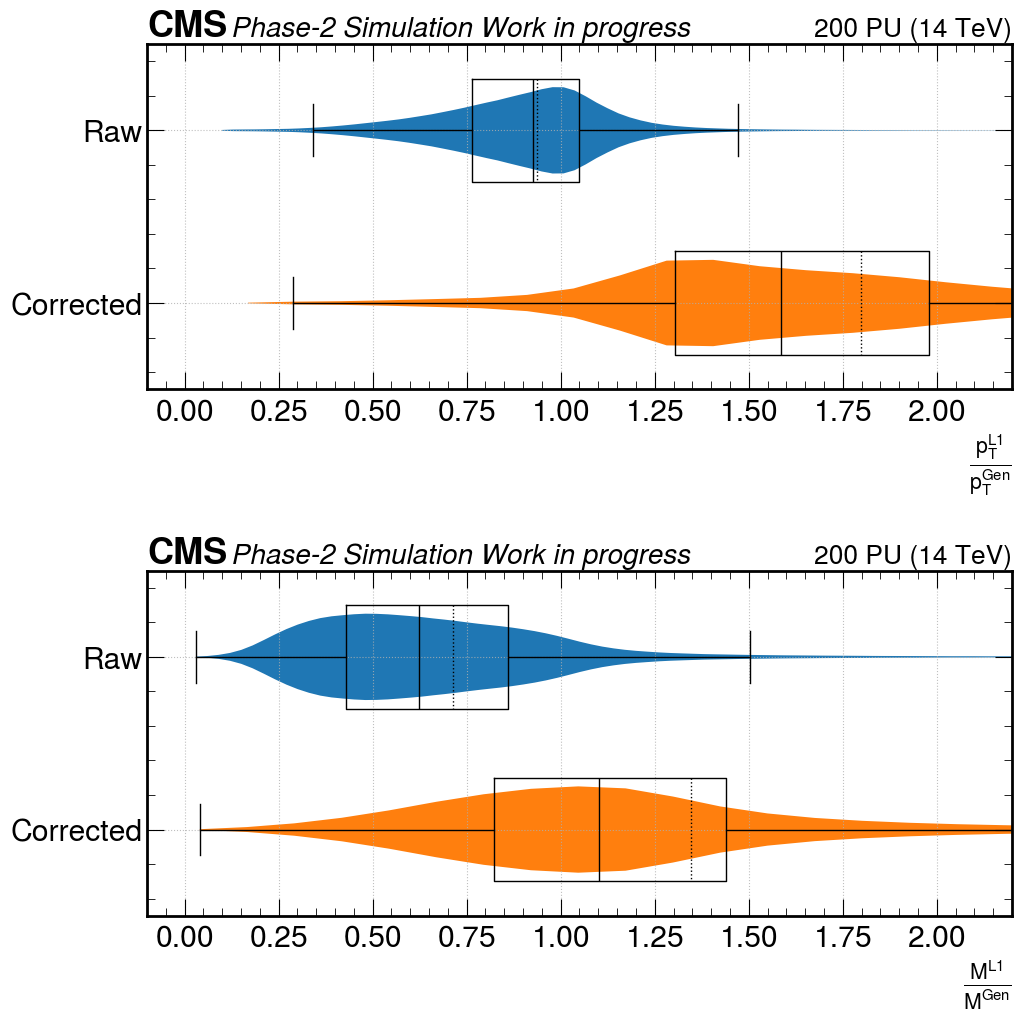

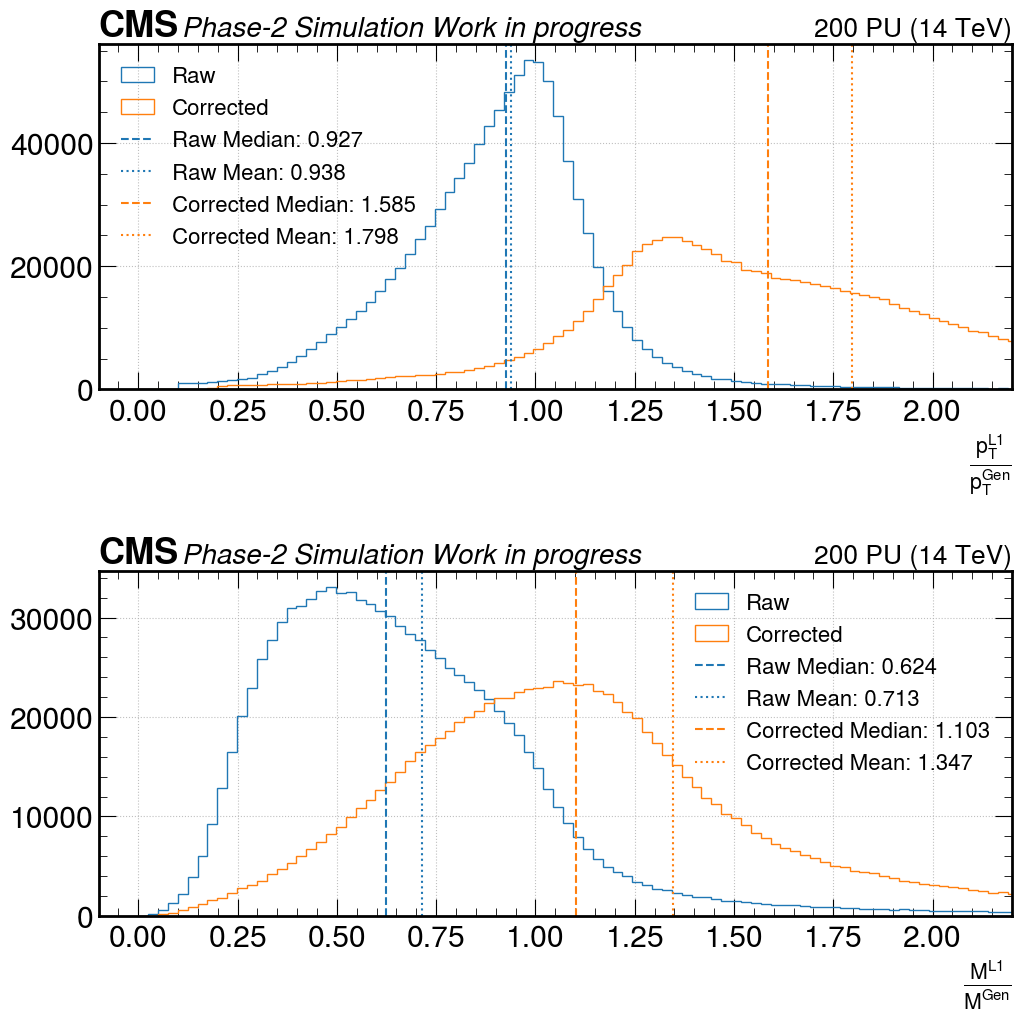

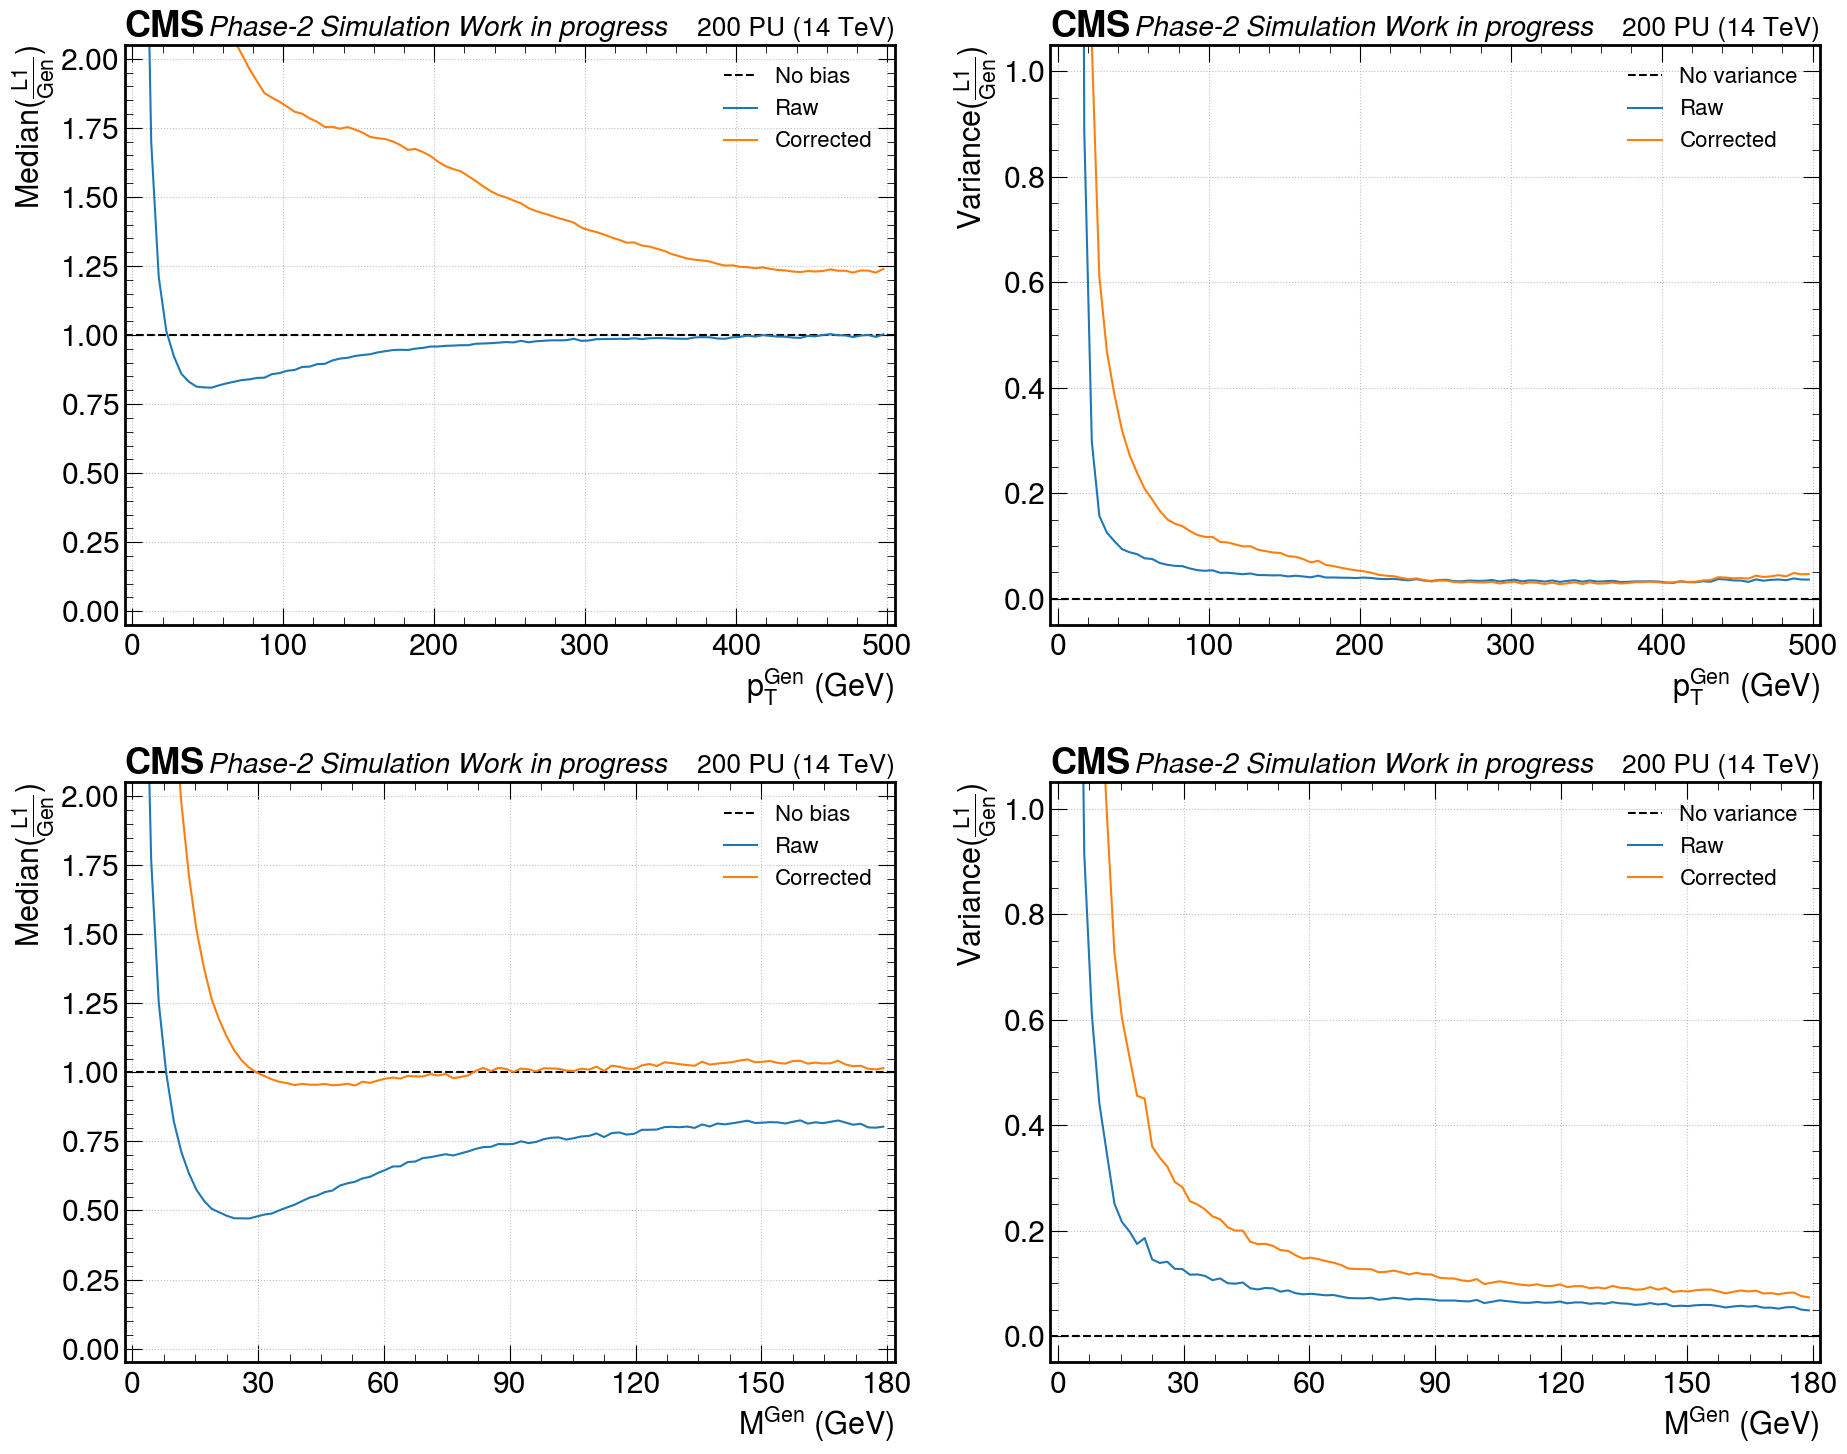

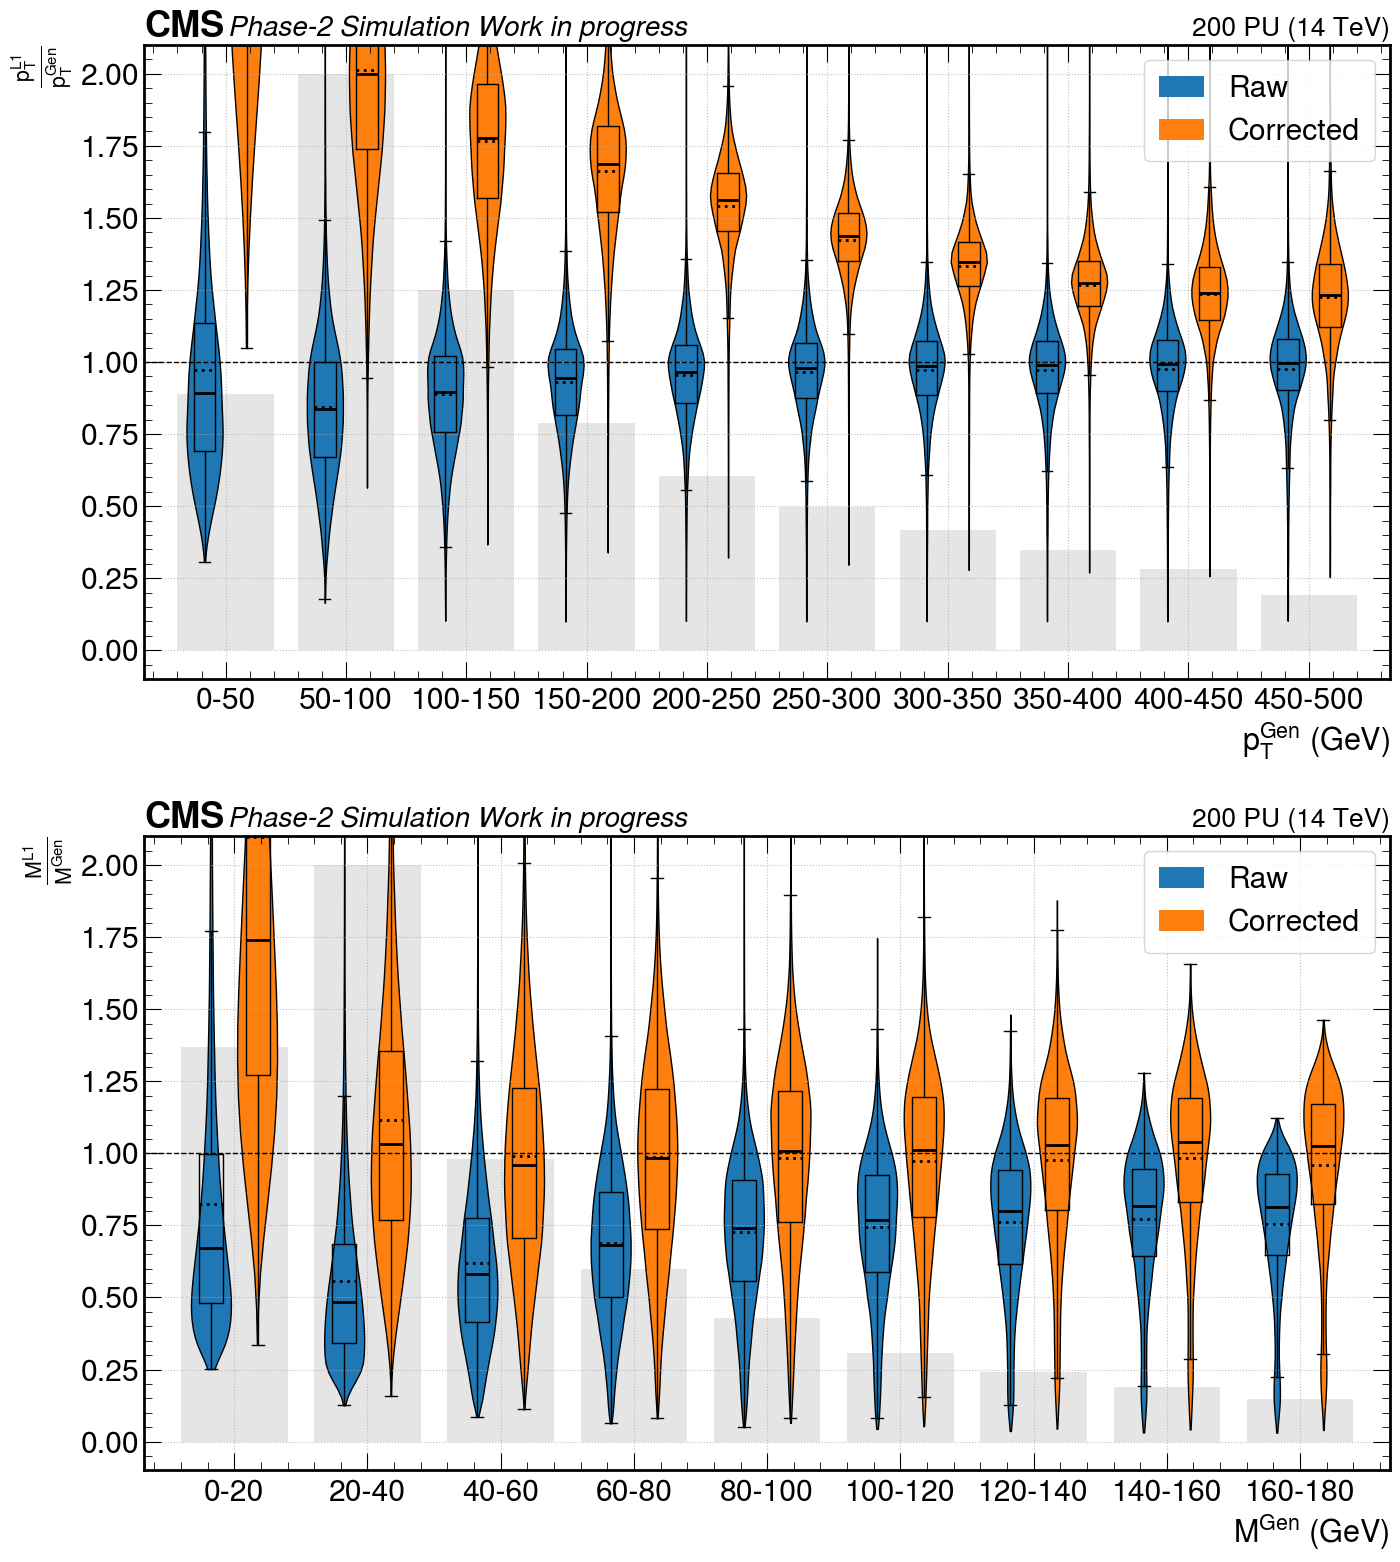

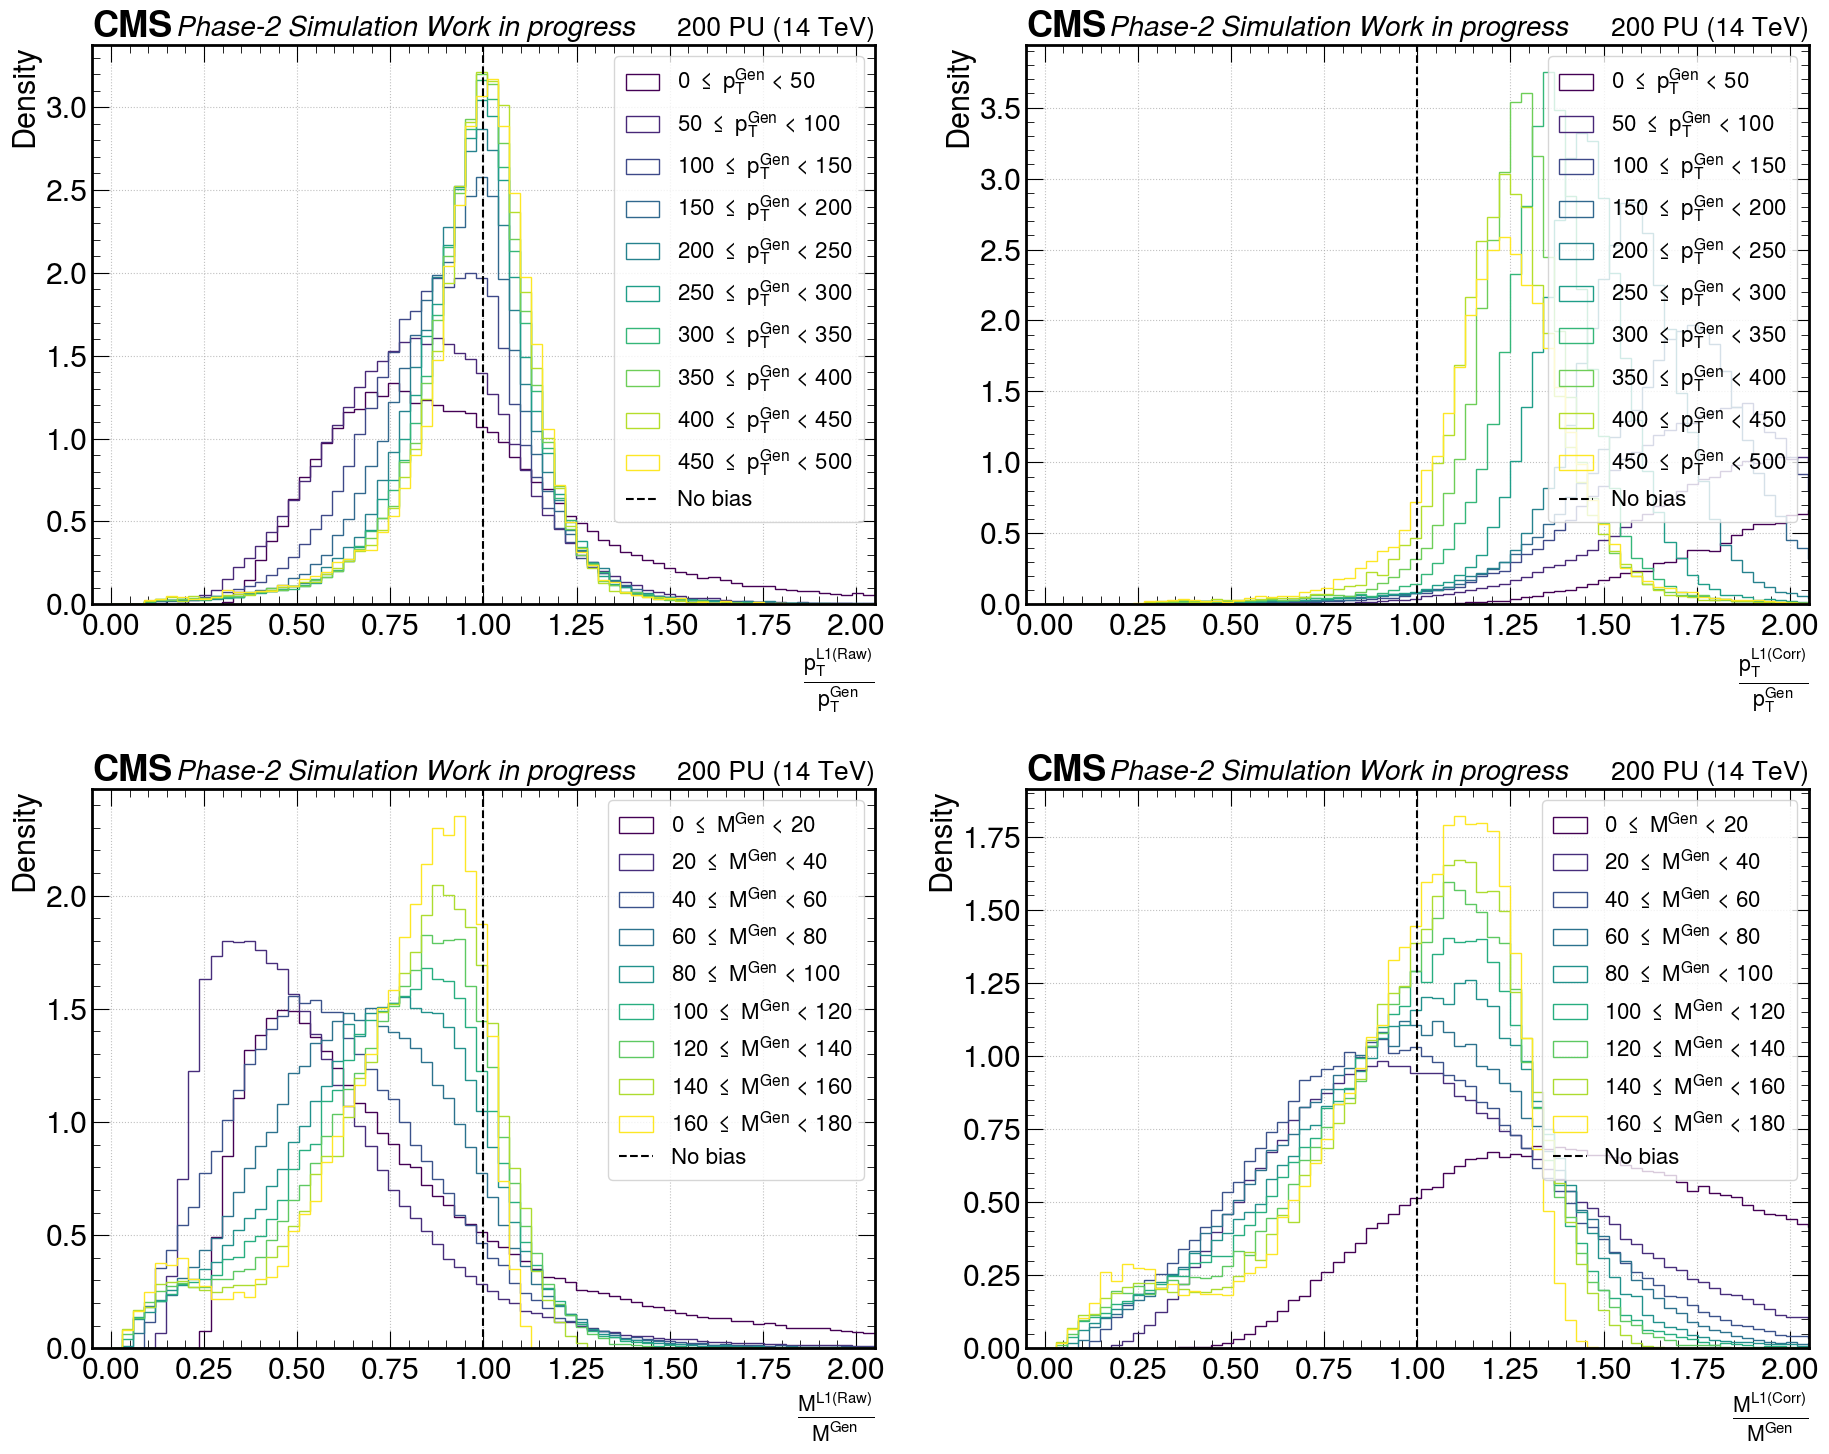

In [114]:
thresholds = Thresholds(l1_pt = (15., 2047), l1_mass=(5., 181.), gen_pt = (1., 2047.), gen_mass = (1., 181.))
plots = Plot(test, thresholds)
plots.make_plots()